In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
atc_df = pd.read_csv("../data/processed/master_atc_trolley_clean.csv")
atc_df.head()

,YEAR_MONTH,Monthly_Trolley_Total,Monthly_Ward_Total,A01,A02,A03,A04,A05,A06,A07,...,S03,V01,V03,V04,V06,V07 1,V07 2,V07 3,V07 4,V07 5
0,2016-01-01,7537,1808,6774.0,322537.0,36323.0,2940.0,1543.0,70781.0,21874.0,...,5613.0,56.0,1843.0,18586.0,46856.0,19127.0,9567.0,14874.0,2354.0,5266.0
1,2016-02-01,6825,2060,7173.0,317940.0,35610.0,2969.0,1510.0,71801.0,21613.0,...,5772.0,70.0,1849.0,18505.0,47634.0,19260.0,9422.0,14601.0,2429.0,5281.0
2,2016-03-01,7018,2363,7477.0,331828.0,37015.0,3174.0,1611.0,72708.0,22847.0,...,5760.0,78.0,1947.0,18569.0,48483.0,19855.0,9802.0,14333.0,2076.0,5257.0
3,2016-04-01,6211,1934,7282.0,330883.0,36708.0,3161.0,1597.0,73287.0,23338.0,...,5753.0,94.0,1957.0,17339.0,48494.0,20268.0,10055.0,13870.0,2241.0,5149.0
4,2016-05-01,5117,1510,7102.0,325370.0,35843.0,3096.0,1555.0,72389.0,23325.0,...,5583.0,84.0,1889.0,16259.0,48695.0,20399.0,9873.0,13280.0,2597.0,5001.0


In [6]:
atc_df["YEAR_MONTH"] = pd.to_datetime(atc_df["YEAR_MONTH"])
atc_df = atc_df.reset_index(drop=True)

In [7]:
atc_df["Monthly_Total_Pressure"] = (
    atc_df["Monthly_Trolley_Total"] + atc_df["Monthly_Ward_Total"]
)

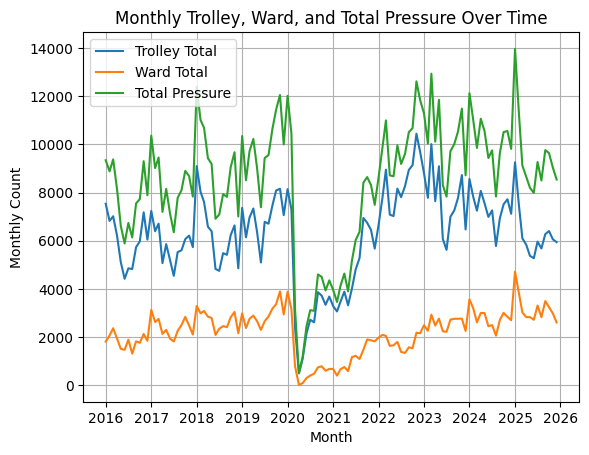

In [9]:
plt.plot(atc_df["YEAR_MONTH"], atc_df["Monthly_Trolley_Total"], label="Trolley Total")
plt.plot(atc_df["YEAR_MONTH"], atc_df["Monthly_Ward_Total"], label="Ward Total")
plt.plot(atc_df["YEAR_MONTH"], atc_df["Monthly_Total_Pressure"], label="Total Pressure")

plt.title("Monthly Trolley, Ward, and Total Pressure Over Time")
plt.xlabel("Month")
plt.ylabel("Monthly Count")
plt.legend()
plt.grid(True)
plt.show()

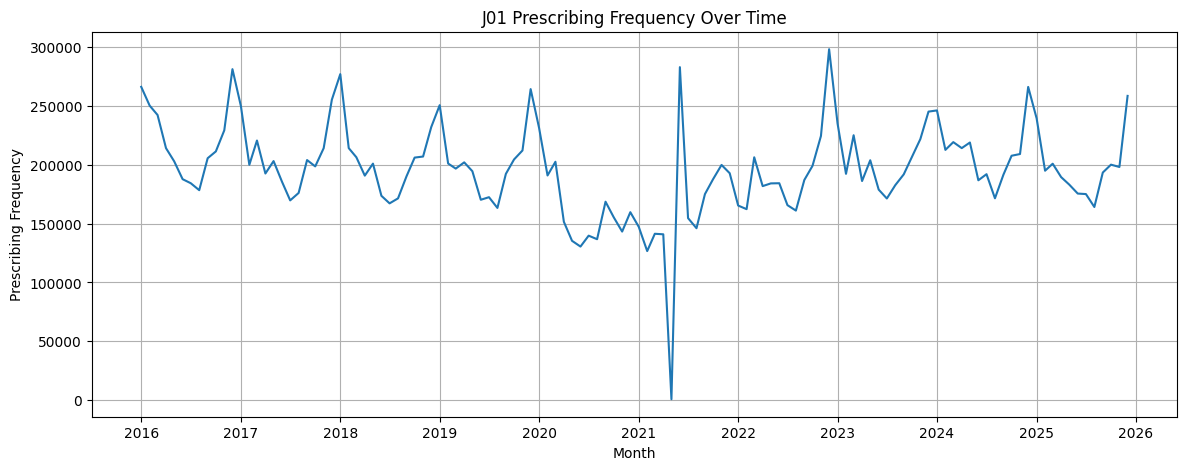

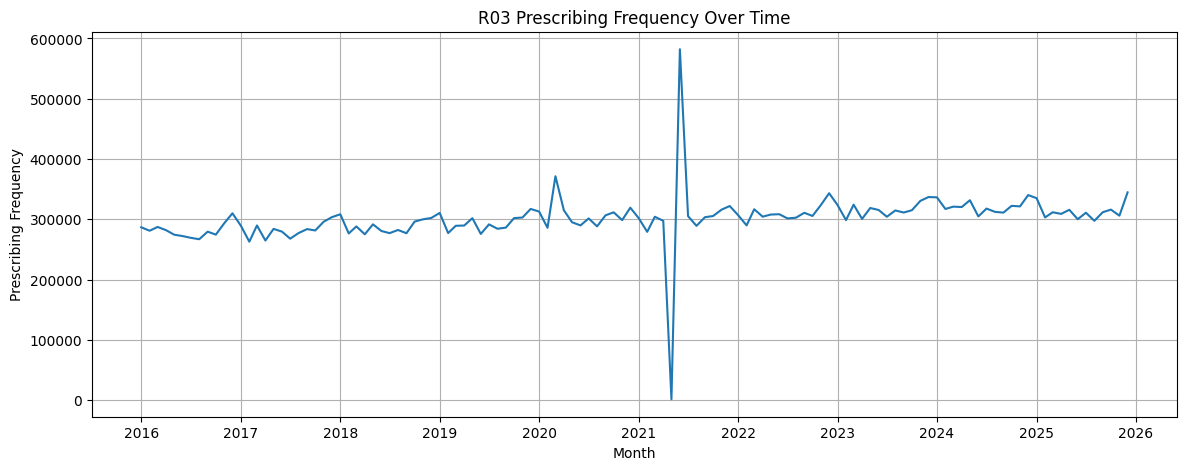

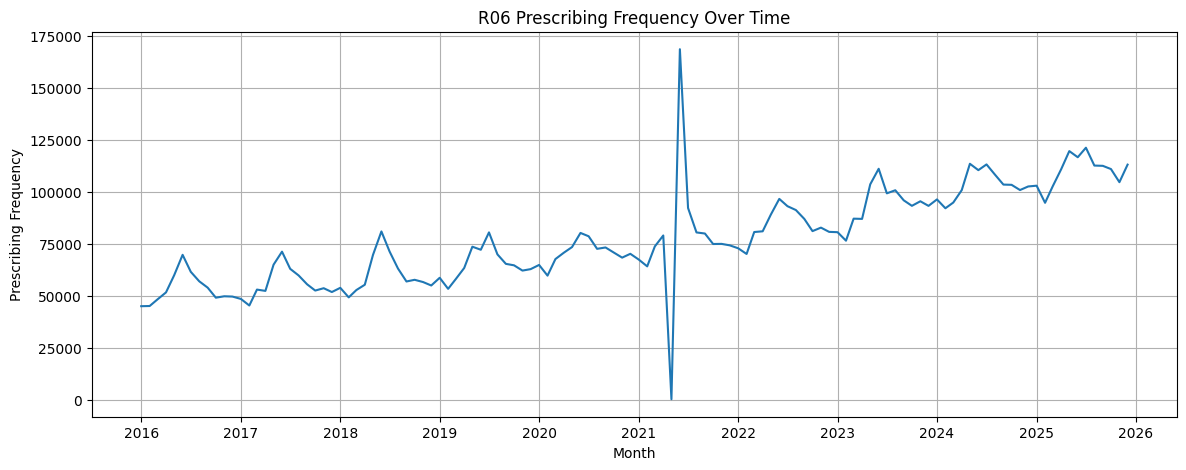

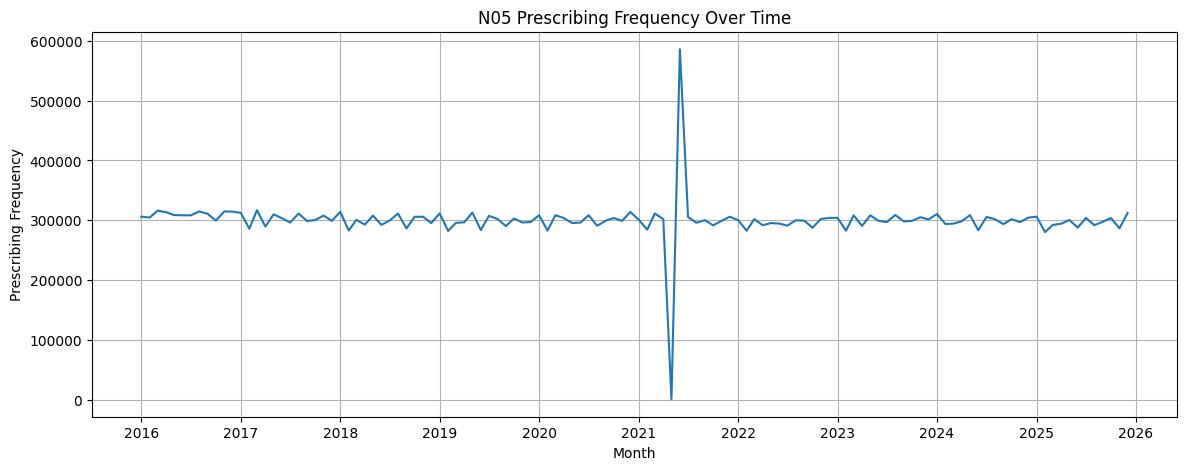

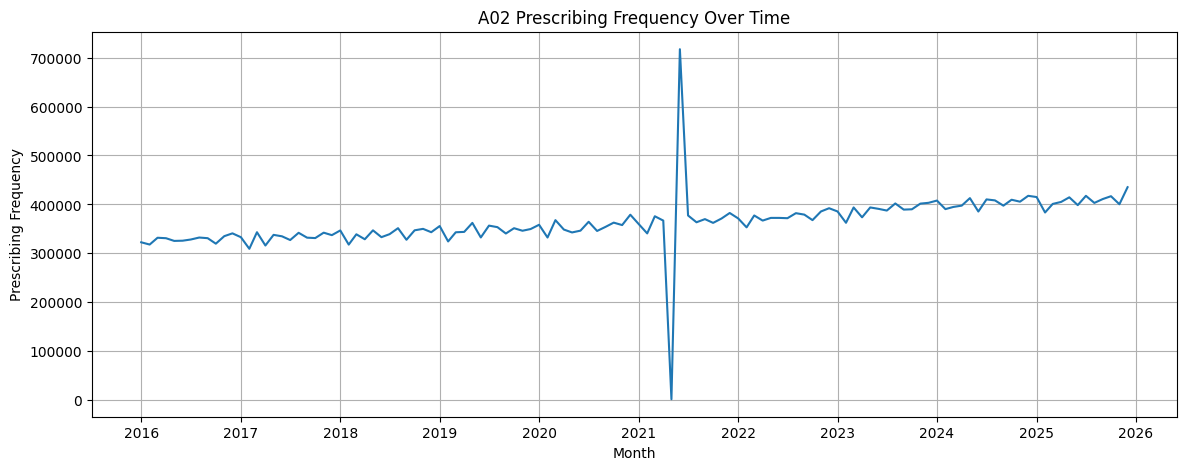

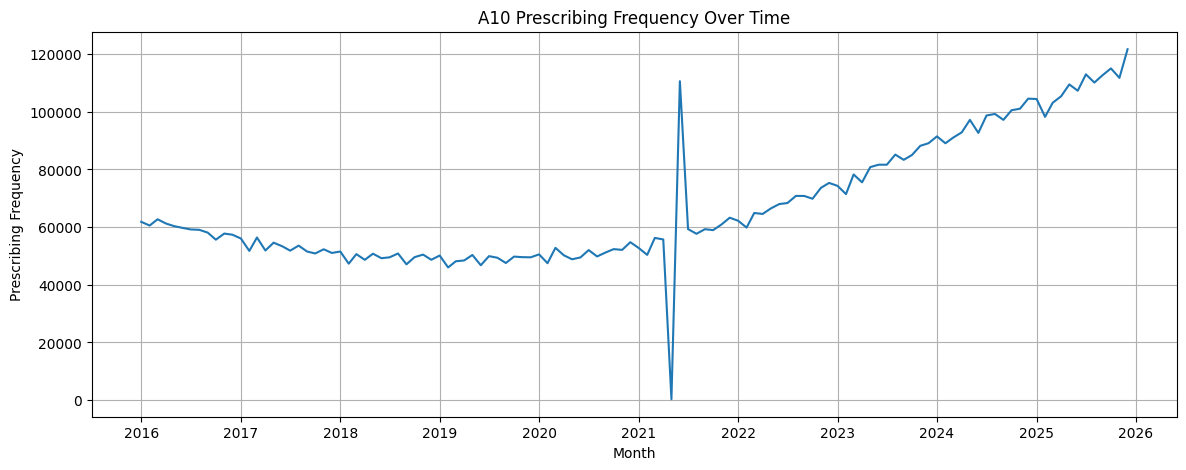

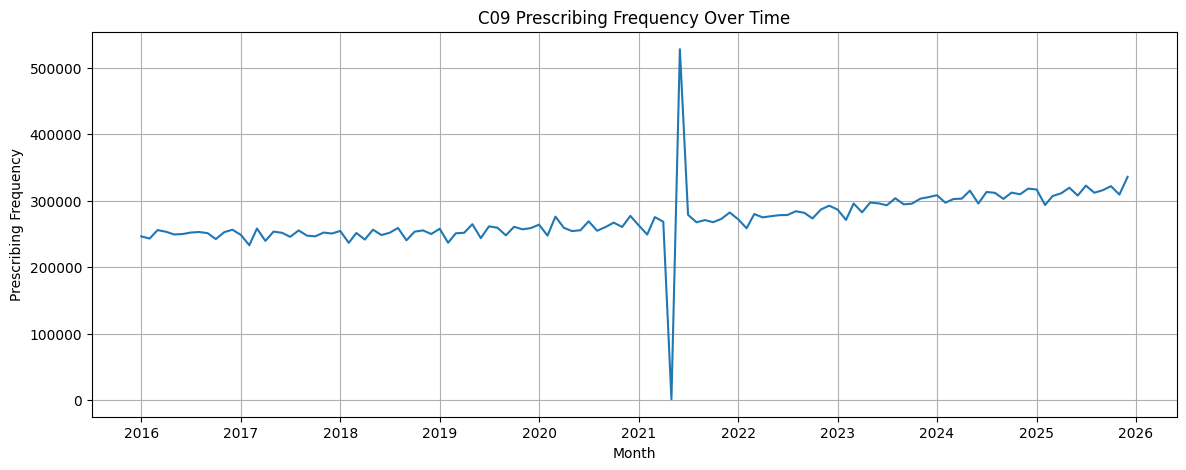

In [ ]:
candidate_classes = ["J01", "R03", "R06", "N05", "A02", "A10", "C09"]

for col in candidate_classes:
    plt.figure(figsize=(14, 5))
    plt.plot(atc_df["YEAR_MONTH"], atc_df[col])
    plt.title(f"{col} Prescribing Frequency Over Time")
    plt.xlabel("Month")
    plt.ylabel("Prescribing Frequency")
    plt.grid(True)
    plt.show()

In [12]:
candidate_classes = ["J01", "R03", "R06", "N05", "A02", "A10", "C09"]

atc_df.loc[
    (atc_df["YEAR_MONTH"] >= "2021-01-01") & 
    (atc_df["YEAR_MONTH"] <= "2021-12-01"),
    ["YEAR_MONTH", "Monthly_Trolley_Total", "Monthly_Ward_Total"] + candidate_classes
]

,YEAR_MONTH,Monthly_Trolley_Total,Monthly_Ward_Total,J01,R03,R06,N05,A02,A10,C09
60,2021-01-01,3285,673,147295.0,301762.0,67403.0,301065.0,359687.0,52754.0,262869.0
61,2021-02-01,3061,395,126670.0,279125.0,64148.0,284402.0,340696.0,50373.0,249095.0
62,2021-03-01,3467,659,141400.0,304190.0,73716.0,311496.0,375745.0,56259.0,275275.0
63,2021-04-01,3884,753,140946.0,297435.0,78977.0,301992.0,366914.0,55730.0,268440.0
64,2021-05-01,3317,581,621.0,1532.0,334.0,1260.0,1810.0,318.0,1665.0
65,2021-06-01,4015,1164,283174.0,582059.0,168430.0,585839.0,717131.0,110613.0,527576.0
66,2021-07-01,4810,1218,154713.0,305192.0,92179.0,305538.0,377349.0,59321.0,278746.0
67,2021-08-01,5281,1086,146120.0,289087.0,80440.0,295954.0,363449.0,57696.0,267525.0
68,2021-09-01,6947,1467,175144.0,303422.0,79913.0,300433.0,369905.0,59289.0,270846.0
69,2021-10-01,6749,1896,187892.0,305404.0,74881.0,291636.0,362214.0,58956.0,267646.0


In [13]:
atc_df.loc[
    atc_df[candidate_classes].sum(axis=1).sort_values().index[:5],
    ["YEAR_MONTH"] + candidate_classes
]

,YEAR_MONTH,J01,R03,R06,N05,A02,A10,C09
64,2021-05-01,621.0,1532.0,334.0,1260.0,1810.0,318.0,1665.0
13,2017-02-01,200087.0,262835.0,45339.0,286025.0,309239.0,51756.0,233037.0
61,2021-02-01,126670.0,279125.0,64148.0,284402.0,340696.0,50373.0,249095.0
15,2017-04-01,192673.0,264761.0,52362.0,289654.0,315983.0,51895.0,239586.0
37,2019-02-01,201172.0,277107.0,53345.0,282330.0,324289.0,46016.0,236831.0


In [15]:
atc_adj = atc_df.copy()


non_prescribing_cols = [
    "YEAR_MONTH",
    "Monthly_Trolley_Total",
    "Monthly_Ward_Total",
    "Monthly_Total_Pressure",
    "Month_Number",
    "Year"
]

prescribing_cols = [
    col for col in atc_adj.columns 
    if col not in non_prescribing_cols
]

may_2021 = atc_adj["YEAR_MONTH"] == "2021-05-01"
jun_2021 = atc_adj["YEAR_MONTH"] == "2021-06-01"

two_month_average = (
    atc_adj.loc[may_2021, prescribing_cols].values +
    atc_adj.loc[jun_2021, prescribing_cols].values
) / 2

atc_adj.loc[may_2021, prescribing_cols] = two_month_average
atc_adj.loc[jun_2021, prescribing_cols] = two_month_average

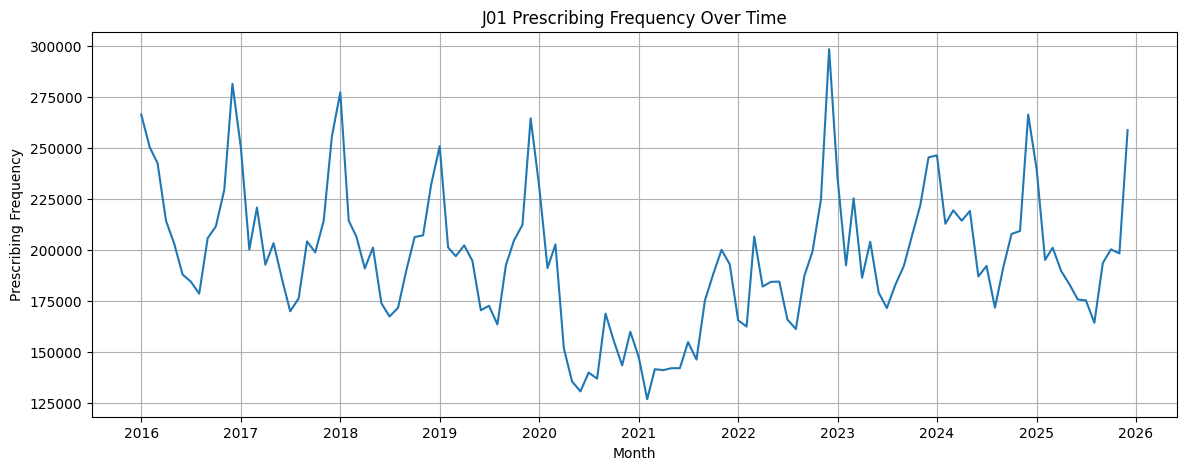

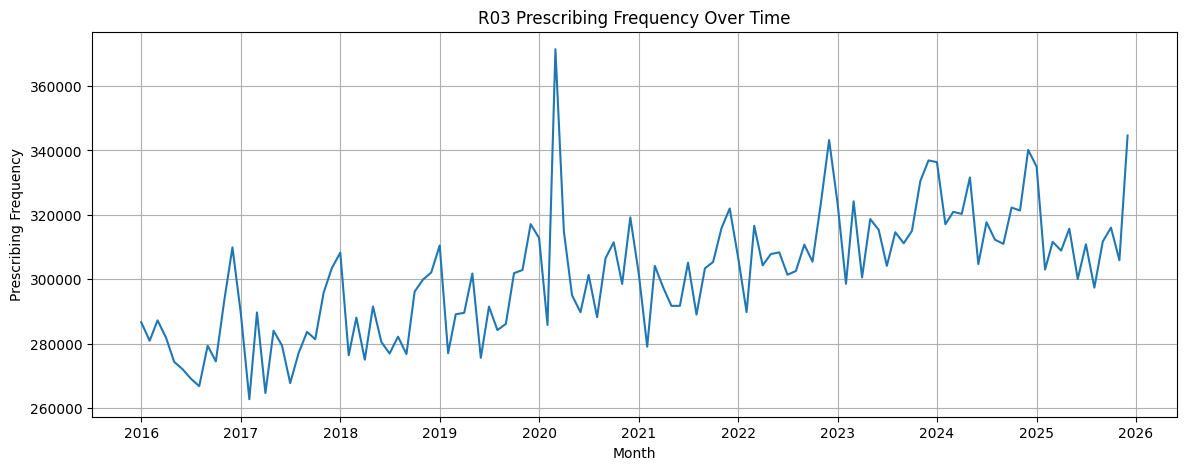

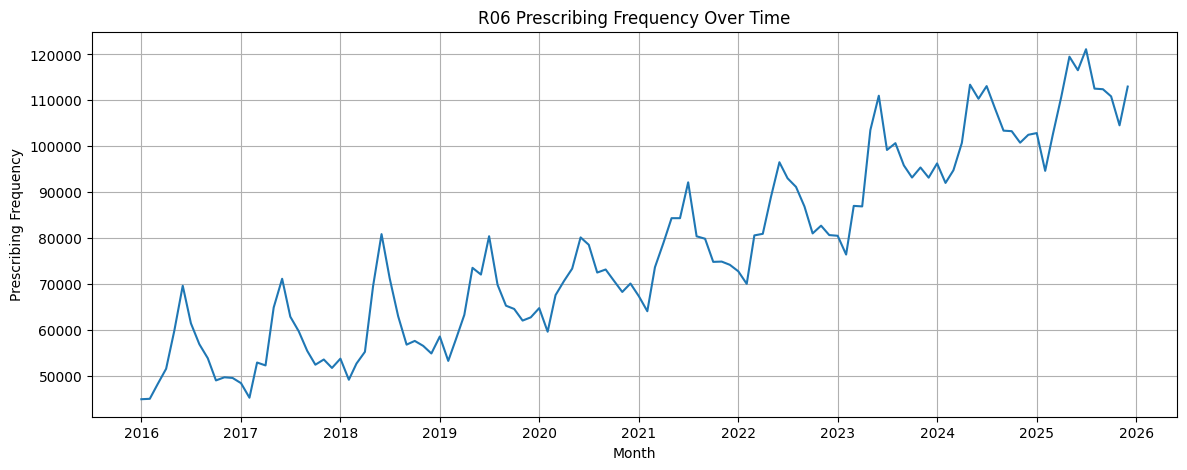

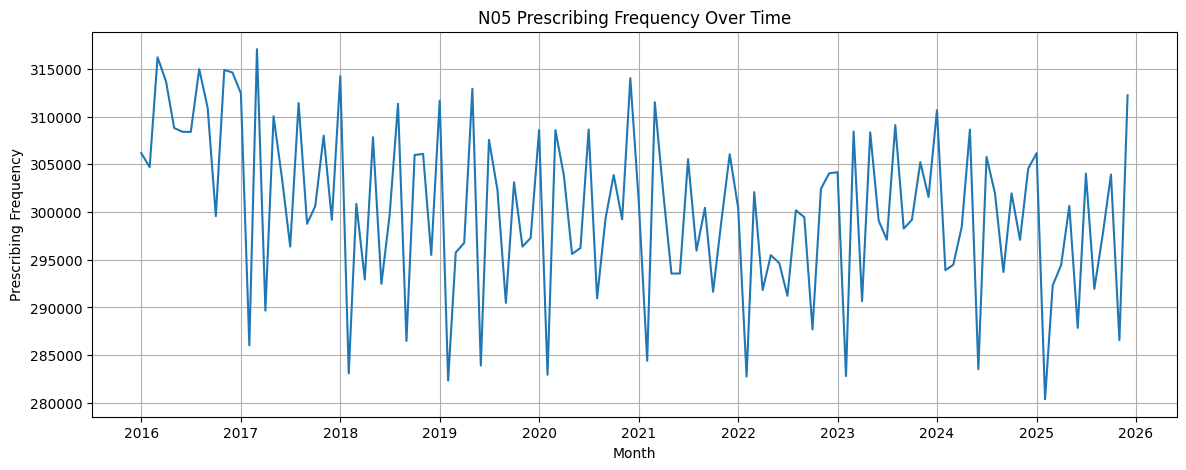

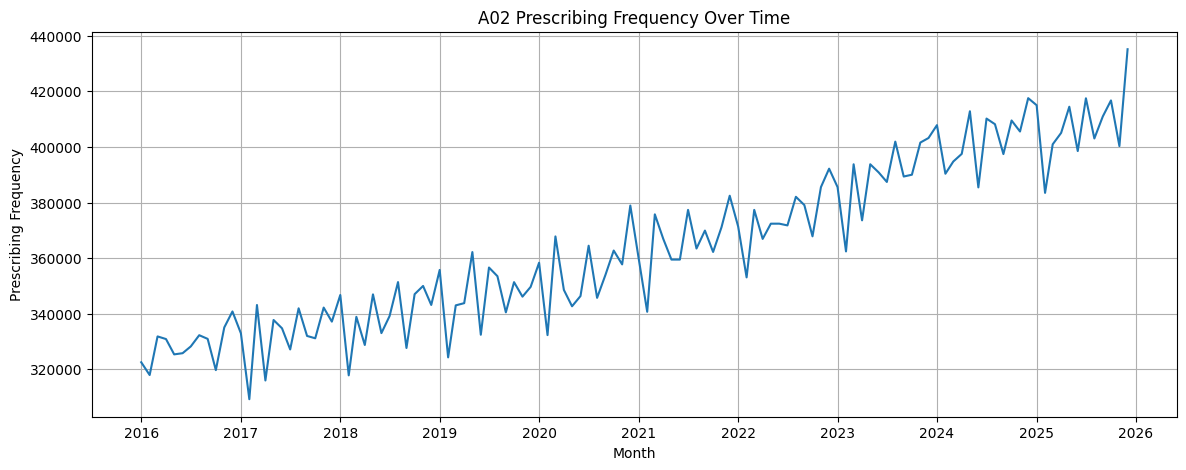

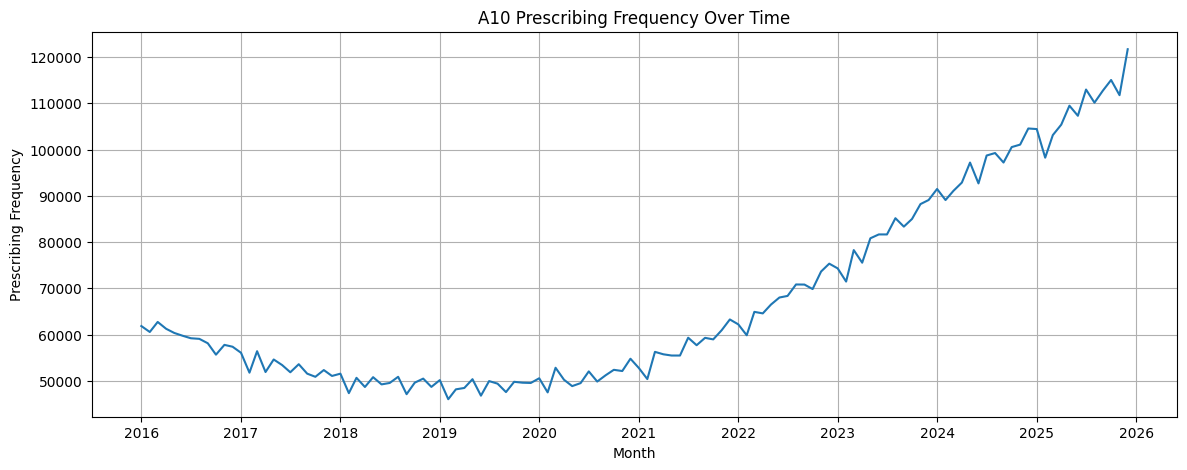

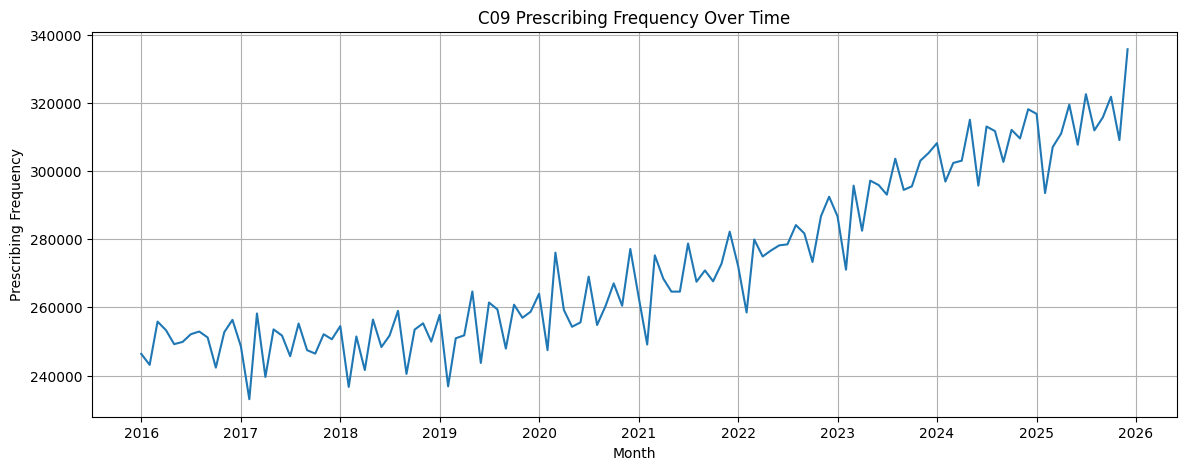

In [18]:
candidate_classes = ["J01", "R03", "R06", "N05", "A02", "A10", "C09"]

for col in candidate_classes:
    plt.figure(figsize=(14, 5))
    plt.plot(atc_adj["YEAR_MONTH"], atc_adj[col])
    plt.title(f"{col} Prescribing Frequency Over Time")
    plt.xlabel("Month")
    plt.ylabel("Prescribing Frequency")
    plt.grid(True)
    plt.show()

In [20]:
atc_adj.to_csv("../data/processed/master_atc_trolley_eda_adjusted.csv", index=False)

In [21]:
atc_adj["Month_Number"] = atc_adj["YEAR_MONTH"].dt.month

monthly_pressure_avg = atc_adj.groupby("Month_Number")[
    ["Monthly_Trolley_Total", "Monthly_Ward_Total", "Monthly_Total_Pressure"]
].mean()

monthly_pressure_avg

,Monthly_Trolley_Total,Monthly_Ward_Total,Monthly_Total_Pressure
Month_Number,,,
1,7596.0,2850.6,10446.6
2,6861.3,2494.1,9355.4
3,6646.3,2298.7,8945.0
4,5821.5,2049.0,7870.5
5,5719.4,2015.1,7734.5
6,5220.5,1843.3,7063.8
7,5511.1,1970.0,7481.1
8,5716.3,1937.1,7653.4
9,6442.9,2263.6,8706.5


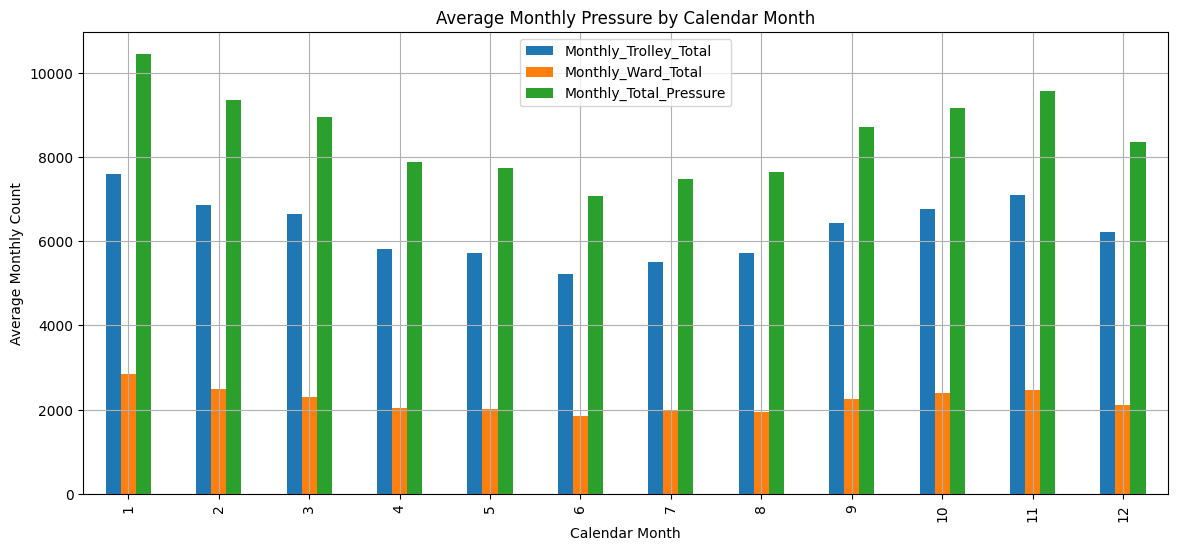

In [22]:
monthly_pressure_avg.plot(kind="bar", figsize=(14, 6))

plt.title("Average Monthly Pressure by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Monthly Count")
plt.grid(True)
plt.show()

In [23]:
candidate_classes = ["J01", "R03", "R06", "N05", "A02", "A10", "C09"]

monthly_prescribing_avg = atc_adj.groupby("Month_Number")[candidate_classes].mean()

monthly_prescribing_avg

,J01,R03,R06,N05,A02,A10,C09
Month_Number,,,,,,,
1,230980.90,311107.00,69079.0,307560.10,365570.90,65532.00,271781.00
2,194621.00,287103.40,65016.3,286332.50,343158.30,62216.00,256622.20
3,206276.20,310336.50,71851.2,304724.10,366715.50,66437.10,275284.00
4,186459.80,295797.90,75180.9,297423.90,357791.70,65458.30,268544.40
5,186977.75,301265.25,85129.8,304183.95,366779.65,67438.75,275118.55
6,171586.35,291806.85,89298.4,294316.15,357896.85,66376.05,269138.25
7,169294.80,294645.00,87349.1,302426.40,367979.60,68357.40,276593.90
8,165207.50,291494.50,81535.6,303019.90,368340.00,68582.30,276036.20
9,190039.80,298091.00,78345.4,297550.00,363187.60,67893.00,271282.50


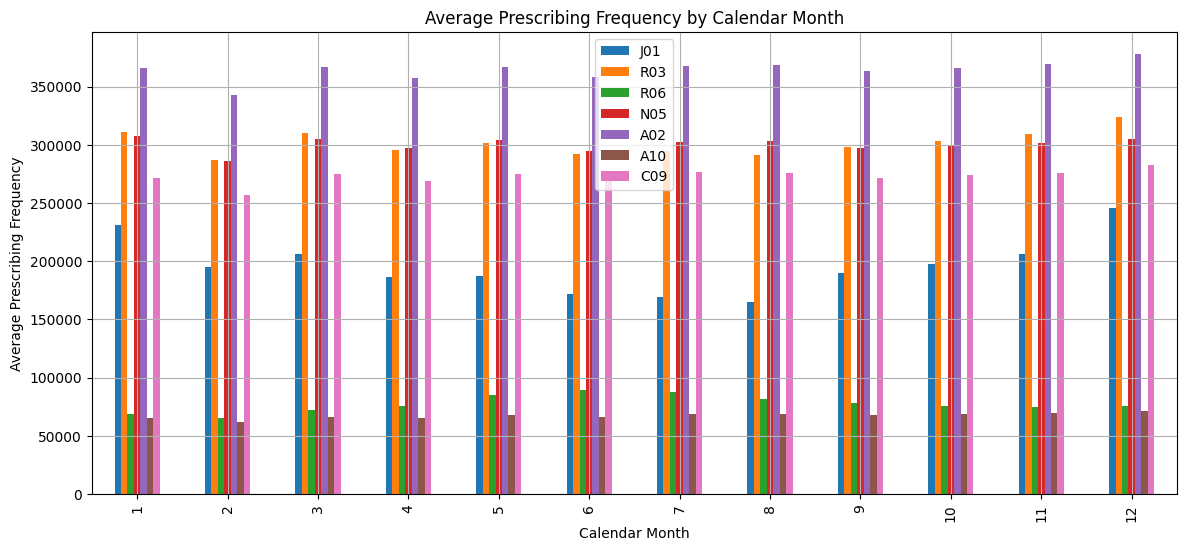

In [24]:
monthly_prescribing_avg.plot(kind="bar", figsize=(14, 6))

plt.title("Average Prescribing Frequency by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Prescribing Frequency")
plt.grid(True)
plt.show()

In [25]:
monthly_prescribing_norm = monthly_prescribing_avg.copy()

for col in monthly_prescribing_norm.columns:
    monthly_prescribing_norm[col] = (
        monthly_prescribing_norm[col] - monthly_prescribing_norm[col].mean()
    ) / monthly_prescribing_norm[col].std()

monthly_prescribing_norm

,J01,R03,R06,N05,A02,A10,C09
Month_Number,,,,,,,
1,1.459745,0.917481,-1.136357,1.251964,0.157737,-0.763943,-0.153004
2,-0.053311,-1.362110,-1.691190,-2.413094,-2.482430,-2.146009,-2.545896
3,0.431701,0.844307,-0.757766,0.762313,0.292569,-0.386709,0.399962
4,-0.392925,-0.536405,-0.303037,-0.498105,-0.758640,-0.794660,-0.663917
5,-0.371372,-0.017177,1.055658,0.669054,0.300126,0.030766,0.373845
6,-1.011859,-0.915430,1.624952,-1.034674,-0.746253,-0.412154,-0.570175
7,-1.107218,-0.645894,1.358741,0.365603,0.441478,0.413647,0.606737
8,-1.277304,-0.945093,0.564807,0.468074,0.483932,0.507383,0.518701
9,-0.243950,-0.318632,0.129130,-0.476333,-0.123012,0.220091,-0.231694


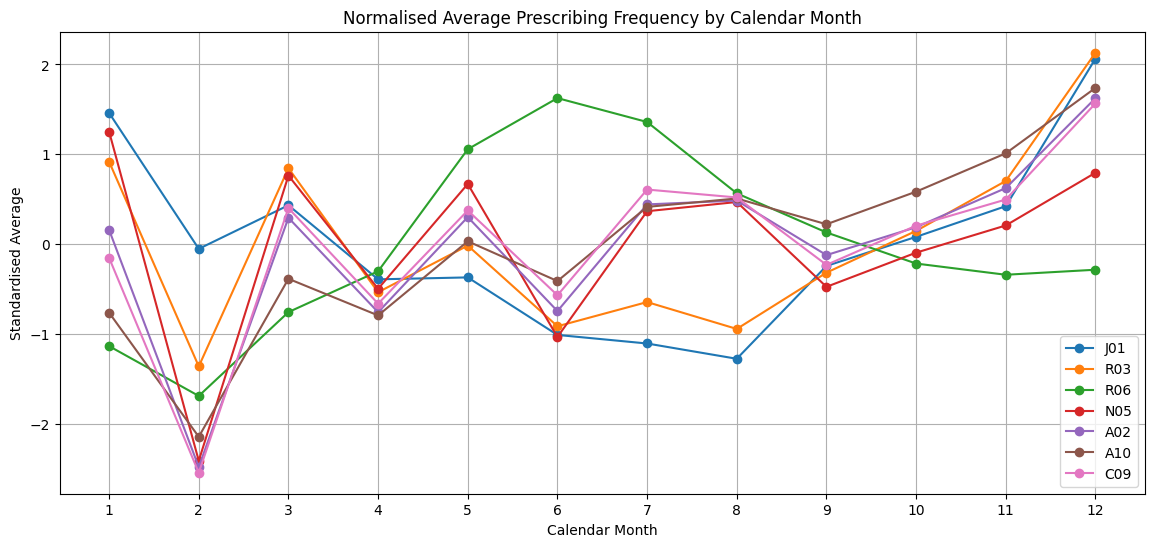

In [26]:
monthly_prescribing_norm.plot(figsize=(14, 6), marker="o")

plt.title("Normalised Average Prescribing Frequency by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Standardised Average")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [35]:
seasonal_compare = atc_adj.groupby("Month_Number")[
    ["Monthly_Total_Pressure", "J01", "R03", "R06"]
].mean()

seasonal_compare_norm = seasonal_compare.copy()

for col in seasonal_compare_norm.columns:
    seasonal_compare_norm[col] = (
        seasonal_compare_norm[col] - seasonal_compare_norm[col].mean()
    ) / seasonal_compare_norm[col].std()

seasonal_compare_norm

,Monthly_Total_Pressure,J01,R03,R06
Month_Number,,,,
1,1.904155,1.459745,0.917481,-1.136357
2,0.820837,-0.053311,-1.362110,-1.691190
3,0.413401,0.431701,0.844307,-0.757766
4,-0.653339,-0.392925,-0.536405,-0.303037
5,-0.788356,-0.371372,-0.017177,1.055658
6,-1.454212,-1.011859,-0.915430,1.624952
7,-1.039926,-1.107218,-0.645894,1.358741
8,-0.868871,-1.277304,-0.945093,0.564807
9,0.176623,-0.243950,-0.318632,0.129130


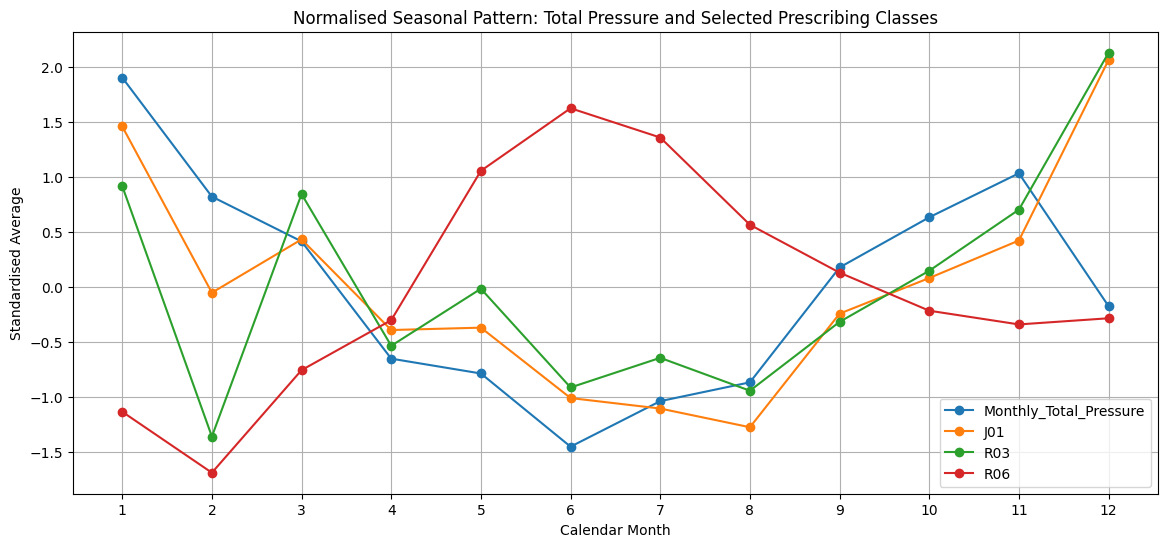

In [36]:
seasonal_compare_norm.plot(figsize=(14, 6), marker="o")

plt.title("Normalised Seasonal Pattern: Total Pressure and Selected Prescribing Classes")
plt.xlabel("Calendar Month")
plt.ylabel("Standardised Average")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [42]:

exclude_cols = [
    "Monthly_Trolley_Total",
    "Monthly_Ward_Total",
    "Monthly_Total_Pressure",
    "Month_Number",
    "YEAR_MONTH"
]

prescribing_cols = [col for col in atc_adj.columns if col not in exclude_cols]

correlations = atc_adj[prescribing_cols].corrwith(
    atc_adj["Monthly_Total_Pressure"]
).sort_values(ascending=False)

correlations.head(15)

S03    0.669752
J01    0.647825
J02    0.633456
R05    0.593313
P02    0.473190
P03    0.464861
J05    0.438225
L01    0.437389
A01    0.426695
H01    0.408204
C05    0.401100
A04    0.384175
V06    0.381142
N07    0.372917
A07    0.369411
dtype: float64

In [43]:
correlations.tail(15)

G02      0.010970
N05      0.000863
D03     -0.015704
C01     -0.048811
V04     -0.052104
J04     -0.078440
V07 5   -0.100495
N01     -0.102979
D07     -0.127317
H04     -0.138530
H02     -0.182694
G01     -0.233134
C04     -0.364718
N03     -0.393574
V03     -0.444430
dtype: float64

In [ ]:
top_corr_classes = correlations.head(10).index.tolist()

['S03', 'J01', 'J02', 'R05', 'P02', 'P03', 'J05', 'L01', 'A01', 'H01']

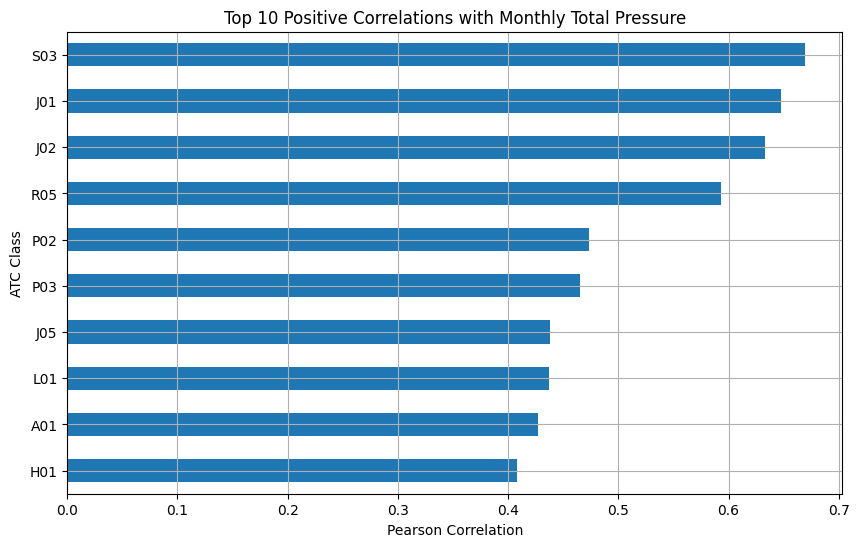

In [45]:
correlations.head(10).sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Positive Correlations with Monthly Total Pressure")
plt.xlabel("Pearson Correlation")
plt.ylabel("ATC Class")
plt.grid(True)
plt.show()

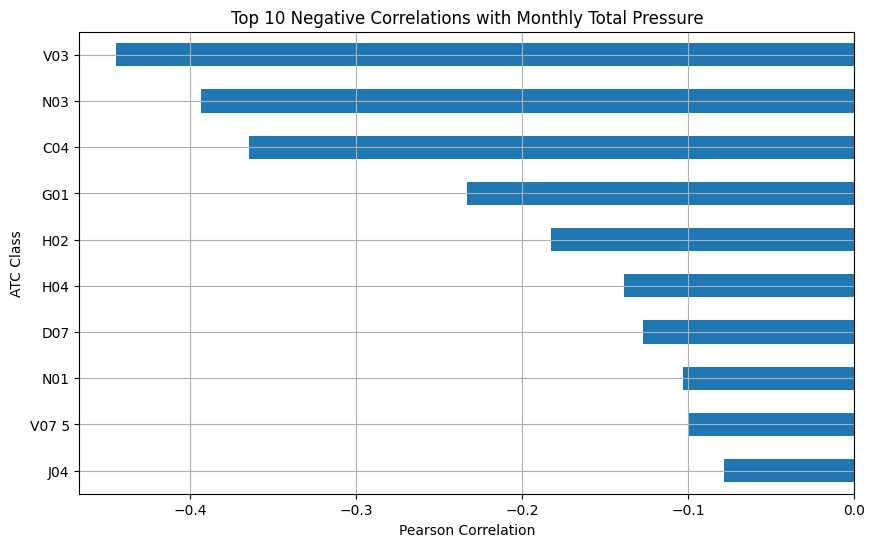

In [46]:
correlations.tail(10).plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Negative Correlations with Monthly Total Pressure")
plt.xlabel("Pearson Correlation")
plt.ylabel("ATC Class")
plt.grid(True)
plt.show()

In [48]:
benzo_path = "../data/processed/master_benzo_trolley_clean.csv"

benzo_df = pd.read_csv(benzo_path)

benzo_df.head()

,YEAR_MONTH,Monthly_Trolley_Total,Monthly_Ward_Total,BENZO_FREQ_N03AE01,BENZO_FREQ_N05BA01,BENZO_FREQ_N05BA02,BENZO_FREQ_N05BA05,BENZO_FREQ_N05BA06,BENZO_FREQ_N05BA08,BENZO_FREQ_N05BA09,...,BENZO_PATIENTS_N05BA09,BENZO_PATIENTS_N05BA11,BENZO_PATIENTS_N05BA12,BENZO_PATIENTS_N05CD01,BENZO_PATIENTS_N05CD02,BENZO_PATIENTS_N05CD05,BENZO_PATIENTS_N05CD07,BENZO_PATIENTS_N05CD08,BENZO_PATIENTS_N05CF01,BENZO_PATIENTS_N05CF02
0,2018-01-01,9104,3291,7319.0,36919.0,2568.0,18.0,3720.0,7418.0,1343.0,...,1133.0,1137.0,28068.0,7980.0,1230.0,5717.0,6421.0,2029.0,42837.0,34878.0
1,2018-02-01,8032,2982,6643.0,33333.0,2140.0,18.0,3387.0,6905.0,1207.0,...,1098.0,1115.0,26592.0,7646.0,1164.0,5429.0,6089.0,1709.0,40471.0,32592.0
2,2018-03-01,7611,3083,7147.0,35477.0,2220.0,14.0,3568.0,7226.0,1265.0,...,1094.0,1127.0,27507.0,7800.0,1203.0,5504.0,6157.0,1788.0,41448.0,33567.0
3,2018-04-01,6586,2847,7002.0,34545.0,2336.0,17.0,3519.0,7052.0,1237.0,...,1092.0,1120.0,27484.0,7656.0,1181.0,5470.0,6075.0,1800.0,40877.0,32983.0
4,2018-05-01,6393,2790,7342.0,36448.0,2341.0,20.0,3659.0,7328.0,1290.0,...,1094.0,1134.0,28275.0,7707.0,1175.0,5510.0,6122.0,1824.0,41309.0,33459.0


In [49]:
benzo_df.columns.tolist()

['YEAR_MONTH',
 'Monthly_Trolley_Total',
 'Monthly_Ward_Total',
 'BENZO_FREQ_N03AE01',
 'BENZO_FREQ_N05BA01',
 'BENZO_FREQ_N05BA02',
 'BENZO_FREQ_N05BA05',
 'BENZO_FREQ_N05BA06',
 'BENZO_FREQ_N05BA08',
 'BENZO_FREQ_N05BA09',
 'BENZO_FREQ_N05BA11',
 'BENZO_FREQ_N05BA12',
 'BENZO_FREQ_N05CD01',
 'BENZO_FREQ_N05CD02',
 'BENZO_FREQ_N05CD05',
 'BENZO_FREQ_N05CD07',
 'BENZO_FREQ_N05CD08',
 'BENZO_FREQ_N05CF01',
 'BENZO_FREQ_N05CF02',
 'BENZO_PATIENTS_N03AE01',
 'BENZO_PATIENTS_N05BA01',
 'BENZO_PATIENTS_N05BA02',
 'BENZO_PATIENTS_N05BA05',
 'BENZO_PATIENTS_N05BA06',
 'BENZO_PATIENTS_N05BA08',
 'BENZO_PATIENTS_N05BA09',
 'BENZO_PATIENTS_N05BA11',
 'BENZO_PATIENTS_N05BA12',
 'BENZO_PATIENTS_N05CD01',
 'BENZO_PATIENTS_N05CD02',
 'BENZO_PATIENTS_N05CD05',
 'BENZO_PATIENTS_N05CD07',
 'BENZO_PATIENTS_N05CD08',
 'BENZO_PATIENTS_N05CF01',
 'BENZO_PATIENTS_N05CF02']

In [50]:
benzo_df["YEAR_MONTH"] = pd.to_datetime(benzo_df["YEAR_MONTH"])

benzo_df = benzo_df.sort_values("YEAR_MONTH").reset_index(drop=True)

benzo_df["Monthly_Total_Pressure"] = (
    benzo_df["Monthly_Trolley_Total"] + benzo_df["Monthly_Ward_Total"]
)

print("Shape:", benzo_df.shape)
print("Date range:", benzo_df["YEAR_MONTH"].min(), "to", benzo_df["YEAR_MONTH"].max())
print("Missing values:", benzo_df.isna().sum().sum())
print("Duplicate months:", benzo_df["YEAR_MONTH"].duplicated().sum())

Shape: (96, 36)
Date range: 2018-01-01 00:00:00 to 2025-12-01 00:00:00
Missing values: 0
Duplicate months: 0


In [51]:
benzo_df.head()

,YEAR_MONTH,Monthly_Trolley_Total,Monthly_Ward_Total,BENZO_FREQ_N03AE01,BENZO_FREQ_N05BA01,BENZO_FREQ_N05BA02,BENZO_FREQ_N05BA05,BENZO_FREQ_N05BA06,BENZO_FREQ_N05BA08,BENZO_FREQ_N05BA09,...,BENZO_PATIENTS_N05BA11,BENZO_PATIENTS_N05BA12,BENZO_PATIENTS_N05CD01,BENZO_PATIENTS_N05CD02,BENZO_PATIENTS_N05CD05,BENZO_PATIENTS_N05CD07,BENZO_PATIENTS_N05CD08,BENZO_PATIENTS_N05CF01,BENZO_PATIENTS_N05CF02,Monthly_Total_Pressure
0,2018-01-01,9104,3291,7319.0,36919.0,2568.0,18.0,3720.0,7418.0,1343.0,...,1137.0,28068.0,7980.0,1230.0,5717.0,6421.0,2029.0,42837.0,34878.0,12395
1,2018-02-01,8032,2982,6643.0,33333.0,2140.0,18.0,3387.0,6905.0,1207.0,...,1115.0,26592.0,7646.0,1164.0,5429.0,6089.0,1709.0,40471.0,32592.0,11014
2,2018-03-01,7611,3083,7147.0,35477.0,2220.0,14.0,3568.0,7226.0,1265.0,...,1127.0,27507.0,7800.0,1203.0,5504.0,6157.0,1788.0,41448.0,33567.0,10694
3,2018-04-01,6586,2847,7002.0,34545.0,2336.0,17.0,3519.0,7052.0,1237.0,...,1120.0,27484.0,7656.0,1181.0,5470.0,6075.0,1800.0,40877.0,32983.0,9433
4,2018-05-01,6393,2790,7342.0,36448.0,2341.0,20.0,3659.0,7328.0,1290.0,...,1134.0,28275.0,7707.0,1175.0,5510.0,6122.0,1824.0,41309.0,33459.0,9183


In [52]:
benzo_cols = [
    col for col in benzo_df.columns 
    if col.startswith("BENZO_FREQ") or col.startswith("BENZO_PATIENTS")
]

benzo_df.loc[
    (benzo_df["YEAR_MONTH"] >= "2021-04-01") & 
    (benzo_df["YEAR_MONTH"] <= "2021-07-01"),
    ["YEAR_MONTH"] + benzo_cols
]

,YEAR_MONTH,BENZO_FREQ_N03AE01,BENZO_FREQ_N05BA01,BENZO_FREQ_N05BA02,BENZO_FREQ_N05BA05,BENZO_FREQ_N05BA06,BENZO_FREQ_N05BA08,BENZO_FREQ_N05BA09,BENZO_FREQ_N05BA11,BENZO_FREQ_N05BA12,...,BENZO_PATIENTS_N05BA09,BENZO_PATIENTS_N05BA11,BENZO_PATIENTS_N05BA12,BENZO_PATIENTS_N05CD01,BENZO_PATIENTS_N05CD02,BENZO_PATIENTS_N05CD05,BENZO_PATIENTS_N05CD07,BENZO_PATIENTS_N05CD08,BENZO_PATIENTS_N05CF01,BENZO_PATIENTS_N05CF02
39,2021-04-01,7453.0,35284.0,2138.0,16.0,3770.0,6344.0,1147.0,994.0,31541.0,...,994.0,910.0,26738.0,6548.0,674.0,5214.0,5218.0,2191.0,41799.0,34386.0
40,2021-05-01,27.0,154.0,7.0,0.0,15.0,19.0,7.0,1.0,95.0,...,6.0,1.0,85.0,25.0,1.0,7.0,39.0,13.0,203.0,86.0
41,2021-06-01,14702.0,68512.0,4168.0,26.0,7338.0,12326.0,2260.0,1915.0,61154.0,...,1147.0,1007.0,32477.0,7118.0,369.0,5623.0,5789.0,3325.0,46561.0,38579.0
42,2021-07-01,7581.0,36067.0,2245.0,11.0,3910.0,6472.0,1208.0,994.0,32156.0,...,1025.0,873.0,26695.0,6514.0,127.0,5202.0,5169.0,1973.0,41287.0,33841.0


In [74]:
benzo_adj = benzo_df.copy()

benzo_freq_cols = [col for col in benzo_adj.columns if col.startswith("BENZO_FREQ")]
benzo_patient_cols = [col for col in benzo_adj.columns if col.startswith("BENZO_PATIENTS")]

may_2021 = benzo_adj["YEAR_MONTH"] == "2021-05-01"
jun_2021 = benzo_adj["YEAR_MONTH"] == "2021-06-01"

freq_two_month_average = (
    benzo_adj.loc[may_2021, benzo_freq_cols].values +
    benzo_adj.loc[jun_2021, benzo_freq_cols].values
) / 2

benzo_adj.loc[may_2021, benzo_freq_cols] = freq_two_month_average
benzo_adj.loc[jun_2021, benzo_freq_cols] = freq_two_month_average


benzo_adj = benzo_adj.set_index("YEAR_MONTH")

benzo_adj.loc["2021-05-01", benzo_patient_cols] = np.nan
benzo_adj.loc["2021-06-01", benzo_patient_cols] = np.nan

benzo_adj[benzo_patient_cols] = benzo_adj[benzo_patient_cols].interpolate(method="time")

benzo_adj = benzo_adj.reset_index()

benzo_adj["Monthly_Total_Pressure"] = (
    benzo_adj["Monthly_Trolley_Total"] + benzo_adj["Monthly_Ward_Total"]
)

benzo_adj["Total_Benzo_Frequency"] = benzo_adj[benzo_freq_cols].sum(axis=1)
benzo_adj["Total_Benzo_Patients"] = benzo_adj[benzo_patient_cols].sum(axis=1)

In [75]:
benzo_adj.to_csv("../data/processed/master_benzo_trolley_eda_adjusted.csv", index=False)

In [76]:
benzo_freq_cols = [col for col in benzo_adj.columns if col.startswith("BENZO_FREQ")]
benzo_patient_cols = [col for col in benzo_adj.columns if col.startswith("BENZO_PATIENTS")]

In [77]:
benzo_adj["Total_Benzo_Frequency"] = benzo_adj[benzo_freq_cols].sum(axis=1)
benzo_adj["Total_Benzo_Patients"] = benzo_adj[benzo_patient_cols].sum(axis=1)

benzo_adj[[
    "YEAR_MONTH",
    "Monthly_Total_Pressure",
    "Total_Benzo_Frequency",
    "Total_Benzo_Patients"
]]

,YEAR_MONTH,Monthly_Total_Pressure,Total_Benzo_Frequency,Total_Benzo_Patients
0,2018-01-01,12395,214979.0,177770.0
1,2018-02-01,11014,193710.0,167929.0
2,2018-03-01,10694,205510.0,172397.0
3,2018-04-01,9433,199515.0,170825.0
4,2018-05-01,9183,209866.0,173084.0
...,...,...,...,...
91,2025-08-01,8504,180271.0,151425.0
92,2025-09-01,9767,183158.0,153133.0
93,2025-10-01,9643,188006.0,154159.0
94,2025-11-01,9036,176588.0,149999.0


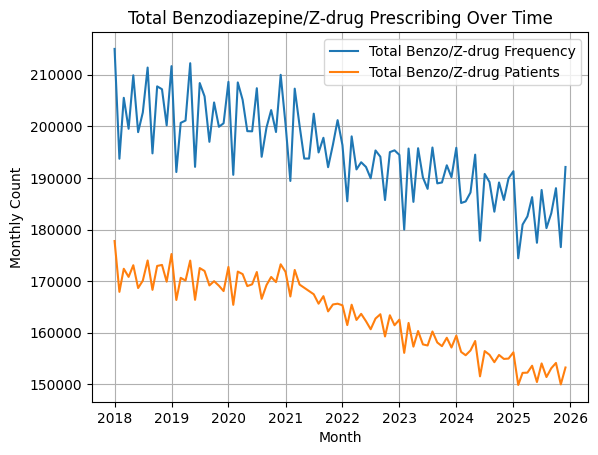

In [78]:
plt.plot(benzo_adj["YEAR_MONTH"], benzo_adj["Total_Benzo_Frequency"], label="Total Benzo/Z-drug Frequency")
plt.plot(benzo_adj["YEAR_MONTH"], benzo_adj["Total_Benzo_Patients"], label="Total Benzo/Z-drug Patients")

plt.title("Total Benzodiazepine/Z-drug Prescribing Over Time")
plt.xlabel("Month")
plt.ylabel("Monthly Count")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
benzo_adj["Month_Number"] = benzo_adj["YEAR_MONTH"].dt.month

benzo_monthly_avg = benzo_adj.groupby("Month_Number")[
    ["Monthly_Total_Pressure", "Total_Benzo_Frequency", "Total_Benzo_Patients"]
].mean()

benzo_monthly_avg

,Monthly_Total_Pressure,Total_Benzo_Frequency,Total_Benzo_Patients
Month_Number,,,
1,10594.500,201699.375,167640.875000
2,9456.125,186234.250,161315.625000
3,8826.250,197757.625,165285.250000
4,7920.125,194075.375,163787.625000
5,7820.500,198053.500,165108.402473
6,7203.500,190151.000,161816.597527
7,7714.875,197132.250,163824.875000
8,7827.125,195852.875,163544.125000
9,8926.625,192363.750,162870.500000


In [80]:
benzo_monthly_norm = benzo_monthly_avg.copy()

for col in benzo_monthly_norm.columns:
    benzo_monthly_norm[col] = (
        benzo_monthly_norm[col] - benzo_monthly_norm[col].mean()
    ) / benzo_monthly_norm[col].std()

benzo_monthly_norm

,Monthly_Total_Pressure,Total_Benzo_Frequency,Total_Benzo_Patients
Month_Number,,,
1,1.931866,1.652637,2.340020
2,0.798282,-2.148268,-1.410613
3,0.171058,0.683862,0.943223
4,-0.731253,-0.221134,0.055189
5,-0.830459,0.756580,0.838360
6,-1.444862,-1.185638,-1.113556
7,-0.935639,0.530162,0.077277
8,-0.823862,0.215727,-0.089198
9,0.271011,-0.641804,-0.488632


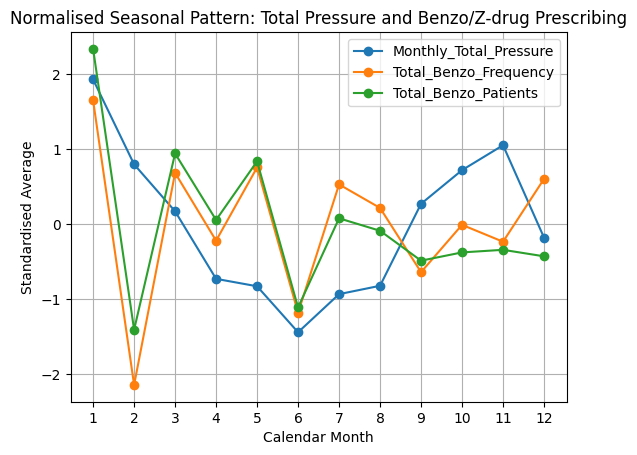

In [81]:
benzo_monthly_norm.plot( marker="o")

plt.title("Normalised Seasonal Pattern: Total Pressure and Benzo/Z-drug Prescribing")
plt.xlabel("Calendar Month")
plt.ylabel("Standardised Average")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [82]:
benzo_corr_cols = [
    "Total_Benzo_Frequency",
    "Total_Benzo_Patients"
] + benzo_freq_cols + benzo_patient_cols

benzo_correlations = benzo_adj[benzo_corr_cols].corrwith(
    benzo_adj["Monthly_Total_Pressure"]
).sort_values(ascending=False)

benzo_correlations.head(15)

BENZO_PATIENTS_N05BA09    0.512154
BENZO_FREQ_N05BA09        0.489950
BENZO_FREQ_N05BA01        0.371317
BENZO_PATIENTS_N05BA01    0.340183
BENZO_FREQ_N05BA05        0.300813
BENZO_PATIENTS_N05BA05    0.292674
BENZO_FREQ_N05CF01        0.071978
BENZO_FREQ_N05BA12       -0.085713
BENZO_FREQ_N05CD08       -0.096122
BENZO_PATIENTS_N05CF01   -0.115302
BENZO_FREQ_N05CF02       -0.124046
BENZO_PATIENTS_N05CD08   -0.127922
BENZO_FREQ_N05BA02       -0.130580
BENZO_PATIENTS_N05BA02   -0.179482
BENZO_FREQ_N05CD07       -0.193423
dtype: float64

In [84]:
benzo_correlations.tail(20)

BENZO_FREQ_N05CD07       -0.193423
BENZO_PATIENTS_N05BA12   -0.202755
Total_Benzo_Frequency    -0.230044
BENZO_FREQ_N05CD05       -0.237519
BENZO_PATIENTS_N05CD07   -0.244687
BENZO_FREQ_N05BA08       -0.271810
BENZO_FREQ_N05BA06       -0.285712
BENZO_PATIENTS_N05BA08   -0.295816
BENZO_FREQ_N05CD01       -0.300094
BENZO_PATIENTS_N05CD01   -0.308330
BENZO_PATIENTS_N05CF02   -0.315373
BENZO_PATIENTS_N05CD05   -0.322387
Total_Benzo_Patients     -0.347156
BENZO_FREQ_N05CD02       -0.352569
BENZO_PATIENTS_N05CD02   -0.366303
BENZO_FREQ_N05BA11       -0.377306
BENZO_PATIENTS_N05BA11   -0.380990
BENZO_PATIENTS_N05BA06   -0.397610
BENZO_FREQ_N03AE01       -0.456553
BENZO_PATIENTS_N03AE01   -0.485479
dtype: float64